## Load Dataset

In [1]:
import pandas as pd
data = pd.read_csv('winequality-white.csv', sep=';')
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


## Prepare Data

In [7]:
data['boolQuality'] = 0

data.loc[data['quality'] > 5, 'boolQuality'] = 1

In [8]:
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,boolQuality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,1
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,1
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,1


In [12]:
# Divide features and labels
X = data.drop(['quality', 'boolQuality'], axis=1)
y = data['boolQuality']

# Normalize data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Separate 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=0.8)

In [13]:
# Store data into DataLoaders
import torch
from torch.utils.data import TensorDataset, DataLoader

train_data = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32), 
    torch.tensor(y_train.to_numpy(), dtype=torch.float32)
)
test_data = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32), 
    torch.tensor(y_test.to_numpy(), dtype=torch.float32)
)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0], drop_last=True)

## ANN

In [15]:
import torch.nn as nn
class ANNModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(p=.20),

            nn.Linear(32, 1)
        )

    def forward(self, X):
        return self.model(X)

## Initialize metaparameters

In [19]:
# Model = ANNModel()
model = ANNModel()

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-4)

# Loss Function
lossfun = nn.BCEWithLogitsLoss()

## Train Model

In [20]:
model = model.to('cuda')

In [27]:
import numpy as np

epochs = 1000

trainAcc = []
testAcc = []
losses = []

for epochi in range(epochs):

    # ===== Train ======
    model.train()
    epoch_loss = 0
    batchAcc = []
    
    for X, y in train_loader:
        X = X.to('cuda')
        y = y.to('cuda')
        
        # Reshape y to match yHat's shape! ([batch_size] -> [batch_size, 1])
        y = y.unsqueeze(1) 

        # Forward
        yHat = model(X)
        loss = lossfun(yHat, y)
        
        # Back
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        
        # Accuracy
        probs = torch.sigmoid(yHat)
        preds = (probs > 0.5).float()

        acc = 100*torch.mean((preds==y).float()).item()
        batchAcc.append(acc)

    trainAcc.append(np.mean(batchAcc))
    losses.append(acc)
    
    # ===== Test =====
    model.eval()
    batchAcc = []

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to('cuda')
            y = y.to('cuda')
            
            # Reshape y here as well
            y = y.unsqueeze(1)

            # FIX: Pass X into the model, not y!
            yHat = model(X)

            # Accuracy
            probs = torch.sigmoid(yHat)
            preds = (probs > 0.5).float()
    
            acc = 100*torch.mean((preds==y).float()).item()
            
            batchAcc.append(acc)
        
        testAcc.append(np.mean(batchAcc))

    # FIX: Use epochi instead of epoch
    print(f"{epochi} | Train: {trainAcc[-1]:.2f} | Test: {testAcc[-1]:.2f}")

0 | Train MAE: 73.18 | Test MAE: 75.41
1 | Train MAE: 74.77 | Test MAE: 77.04
2 | Train MAE: 75.59 | Test MAE: 77.86
3 | Train MAE: 75.95 | Test MAE: 78.06
4 | Train MAE: 76.38 | Test MAE: 78.47
5 | Train MAE: 76.64 | Test MAE: 78.57
6 | Train MAE: 75.92 | Test MAE: 78.57
7 | Train MAE: 76.74 | Test MAE: 78.57
8 | Train MAE: 76.26 | Test MAE: 78.78
9 | Train MAE: 76.77 | Test MAE: 78.67
10 | Train MAE: 76.49 | Test MAE: 79.29
11 | Train MAE: 76.69 | Test MAE: 78.88
12 | Train MAE: 76.66 | Test MAE: 78.88
13 | Train MAE: 76.00 | Test MAE: 79.29
14 | Train MAE: 76.54 | Test MAE: 79.18
15 | Train MAE: 76.87 | Test MAE: 79.18
16 | Train MAE: 77.41 | Test MAE: 79.18
17 | Train MAE: 76.56 | Test MAE: 79.18
18 | Train MAE: 76.97 | Test MAE: 79.49
19 | Train MAE: 77.00 | Test MAE: 79.69
20 | Train MAE: 77.20 | Test MAE: 79.69
21 | Train MAE: 77.28 | Test MAE: 79.80
22 | Train MAE: 77.33 | Test MAE: 79.80
23 | Train MAE: 77.43 | Test MAE: 79.29
24 | Train MAE: 77.38 | Test MAE: 79.80
25 | Train

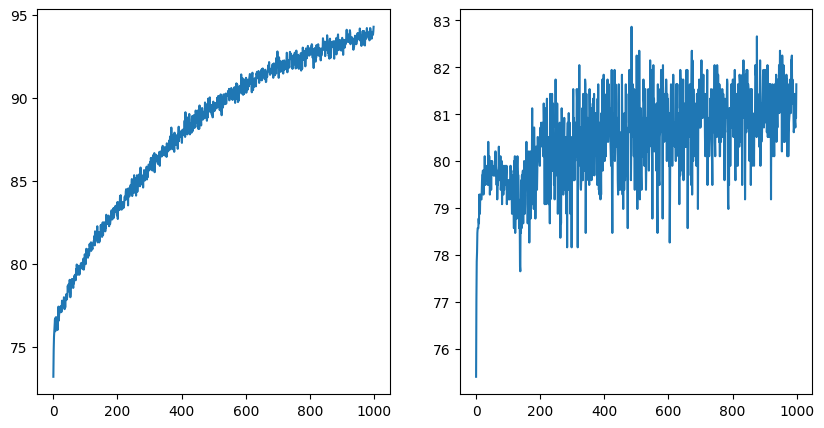

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].plot(trainAcc)

ax[1].plot(testAcc)